# Ballistic Propagation Tests

Visualises atom positions (x, y, z) as a function of time for four scenarios:

1. **Free propagation** — no pulses, assorted initial velocities
2. **LMT kicks** — zero initial velocity, N π-pulses in varying directions
3. **Maxwell–Boltzmann ensemble at 1 µK** with some π-pulses
4. Same but also with an initial position distribution (~100 µm)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import constants
import version_info as vs

import lmt_simulation as sim
from lmt_simulation import (
    make_atom_states,
    transform_state_vector,
    propagate_states_in_borde_representation,
    pulse_interaction_in_borde_representation,
    TRANSITION_FREQUENCY,
    K_WAVEVECTOR,
    RECOIL_VELOCITY,
    T_PI,
    RABI_FREQ,
    MASS_ATOM,
)

In [36]:
# ── Simulation parameters ──────────────────────────────────────────────────
T_TOF = 5e-3          # Total time-of-flight to track (seconds)
N_TIME_STEPS = 200    # Number of time points for trajectory recording
DETUNING_HZ = 0.0    # On-resonance pulses

def maxwell_boltzmann_velocities(temperature_K, n_atoms, rng=None):
    """Draw 3D velocities from a Maxwell–Boltzmann distribution at temperature_K."""
    if rng is None:
        rng = np.random.default_rng(0)
    sigma = np.sqrt(constants.k * temperature_K / MASS_ATOM)
    return rng.normal(0.0, sigma, size=(n_atoms, 3))


def simulate_trajectory(
    position_xyz,
    velocity_xyz,
    pulse_schedule,   # list of (t_start, k_sign) – times at which to fire a π-pulse
    t_end=T_TOF,
    n_steps=N_TIME_STEPS,
):
    """
    Propagate a single atom through free evolution and optional pulses.

    Parameters
    ----------
    position_xyz : (3,) array  – initial position in metres
    velocity_xyz : (3,) array  – initial velocity in m/s
    pulse_schedule : list of (t_pulse_start, k_sign)
        Each entry fires a π-pulse at the given time.
    t_end : float   total evolution time (s)
    n_steps : int   number of snapshot times

    Returns
    -------
    times : (n_steps,)
    traj  : dict with keys 'x', 'y', 'z', each (n_steps,)
        Each value is the *mean* position of the wavefunction (|amp|^2 weighted).
    """
    vx0, vy0, vz0 = float(velocity_xyz[0]), float(velocity_xyz[1]), float(velocity_xyz[2])
    px0, py0, pz0 = float(position_xyz[0]), float(position_xyz[1]), float(position_xyz[2])

    m_values, positions, velocities, internal_amplitude, internal_is_ground = make_atom_states(
        position_x=px0, position_y=py0, position_z=pz0,
        velocity_x=vx0, velocity_y=vy0, initial_velocity_z=vz0,
        c0=1.0, c1=0.0,
    )

    omega_laser = 2 * np.pi * (TRANSITION_FREQUENCY + DETUNING_HZ)

    squiggly_amplitudes = transform_state_vector(
        m_values, internal_amplitude, internal_is_ground,
        omega_laser=omega_laser, t=0.0, z=pz0, vz=vz0, inverse=False,
    )

    # Sort pulse schedule by time
    pulse_schedule_sorted = sorted(pulse_schedule, key=lambda x: x[0])

    snapshot_times = np.linspace(0.0, t_end, n_steps)
    traj_x = np.empty(n_steps)
    traj_y = np.empty(n_steps)
    traj_z = np.empty(n_steps)

    # Build a merged list of events: (time, type) where type='snapshot' or 'pulse'
    events = [(t, 'snapshot', i) for i, t in enumerate(snapshot_times)]
    for t_p, ks in pulse_schedule_sorted:
        events.append((t_p, 'pulse', ks))
    events.sort(key=lambda e: (e[0], 0 if e[1] == 'snapshot' else 1))

    current_time = 0.0

    def _mean_position():
        probs = np.abs(squiggly_amplitudes) ** 2
        total = probs.sum()
        if total < 1e-30:
            return positions.mean(axis=0)
        return (probs[:, None] * positions).sum(axis=0) / total

    def _free_evolve(dt):
        nonlocal m_values, squiggly_amplitudes, internal_is_ground, positions, velocities, current_time
        if dt <= 0:
            return
        m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
            propagate_states_in_borde_representation(
                m_values, squiggly_amplitudes, internal_is_ground,
                positions, velocities,
                time_of_propegation=dt,
                omega_laser=omega_laser,
                vz=vz0,
            )
        )
        current_time += dt

    for event in events:
        t_event = event[0]
        dt = t_event - current_time
        _free_evolve(dt)

        if event[1] == 'snapshot':
            idx = event[2]
            mp = _mean_position()
            traj_x[idx] = mp[0]
            traj_y[idx] = mp[1]
            traj_z[idx] = mp[2]
        else:  # pulse
            k_sign = event[2]
            m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
                pulse_interaction_in_borde_representation(
                    m_values, squiggly_amplitudes, internal_is_ground,
                    positions, velocities,
                    pulse_detuning=DETUNING_HZ,
                    t_pulse=T_PI,
                    pulse_rabi_freq=RABI_FREQ,
                    pulse_phase=0.0,
                    k_sign=k_sign,
                    vz=vz0,
                )
            )

    return snapshot_times, {'x': traj_x, 'y': traj_y, 'z': traj_z}


def plot_xyz_trajectories(ax_x, ax_y, ax_z, times_ms, trajectories, labels=None, colors=None, title_suffix='', alpha=0.75):
    """Plot x, y, z trajectories on three provided Axes."""
    for i, (traj, label) in enumerate(zip(trajectories, labels or [None]*len(trajectories))):
        c = colors[i] if colors is not None else None
        kw = dict(lw=1.2, alpha=alpha, color=c, label=label)
        ax_x.plot(times_ms, traj['x'] * 1e3, **kw)   # convert to mm
        ax_y.plot(times_ms, traj['y'] * 1e3, **kw)
        ax_z.plot(times_ms, traj['z'] * 1e3, **kw)

    for ax, dim in zip([ax_x, ax_y, ax_z], ['x', 'y', 'z']):
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel(f'{dim} (mm)')
        ax.set_title(f'{dim}-position{" - " + title_suffix if title_suffix else ""}')
        ax.grid(True, alpha=0.3)

print(f'Recoil velocity: {RECOIL_VELOCITY*1e3:.4f} mm/s')
print(f'T_PI = {T_PI*1e6:.1f} µs,  RABI_FREQ = {RABI_FREQ:.1f} Hz')

Recoil velocity: 6.5710 mm/s
T_PI = 45.0 µs,  RABI_FREQ = 11111.1 Hz


## 1 · Free propagation — no pulses, assorted initial velocities

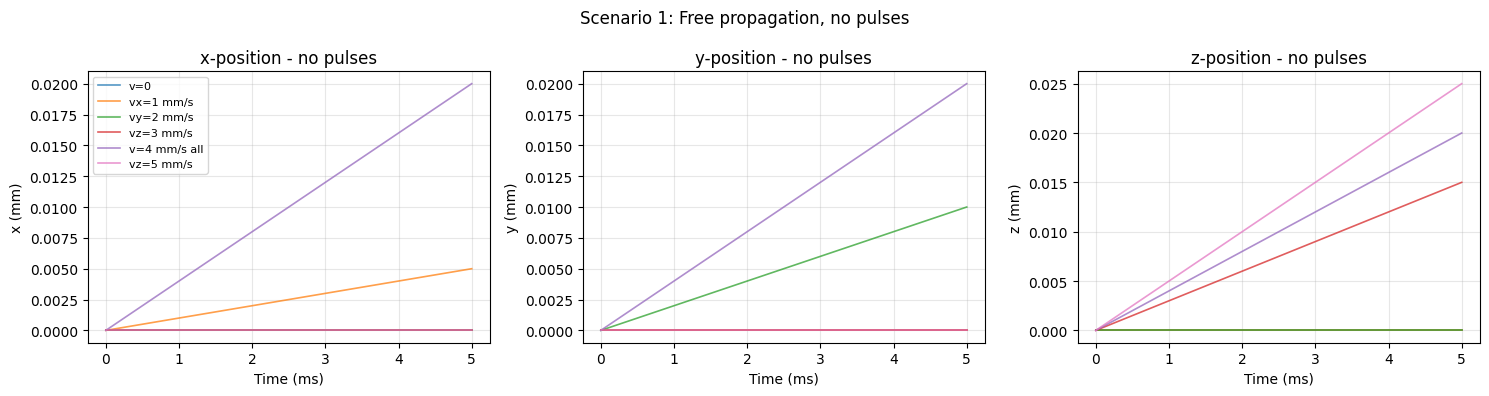

In [23]:
# A spread of initial velocities in all three axes; no pulses
velocity_cases = [
    ([0.0,    0.0,    0.0  ], 'v=0'),
    ([1e-3,   0.0,    0.0  ], 'vx=1 mm/s'),
    ([0.0,    2e-3,   0.0  ], 'vy=2 mm/s'),
    ([0.0,    0.0,    3e-3 ], 'vz=3 mm/s'),
    ([4e-3,   4e-3,   4e-3 ], 'v=4 mm/s all'),
    ([0.0,    0.0,    5e-3 ], 'vz=5 mm/s'),
]

colors1 = cm.tab10(np.linspace(0, 0.6, len(velocity_cases)))
trajectories1 = []
labels1 = []

for vel, label in velocity_cases:
    t, traj = simulate_trajectory(
        position_xyz=np.array([0.0, 0.0, 0.0]),
        velocity_xyz=np.array(vel),
        pulse_schedule=[],
    )
    trajectories1.append(traj)
    labels1.append(label)

times_ms = t * 1e3

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
plot_xyz_trajectories(*axes1, times_ms, trajectories1, labels=labels1, colors=colors1,
                      title_suffix='no pulses')
axes1[0].legend(fontsize=8)
fig1.suptitle('Scenario 1: Free propagation, no pulses', fontsize=12)
vs.tag_plot(small=True)
fig1.tight_layout()
plt.show()

## 2 · LMT kicks — zero initial velocity, N π-pulses in varying directions

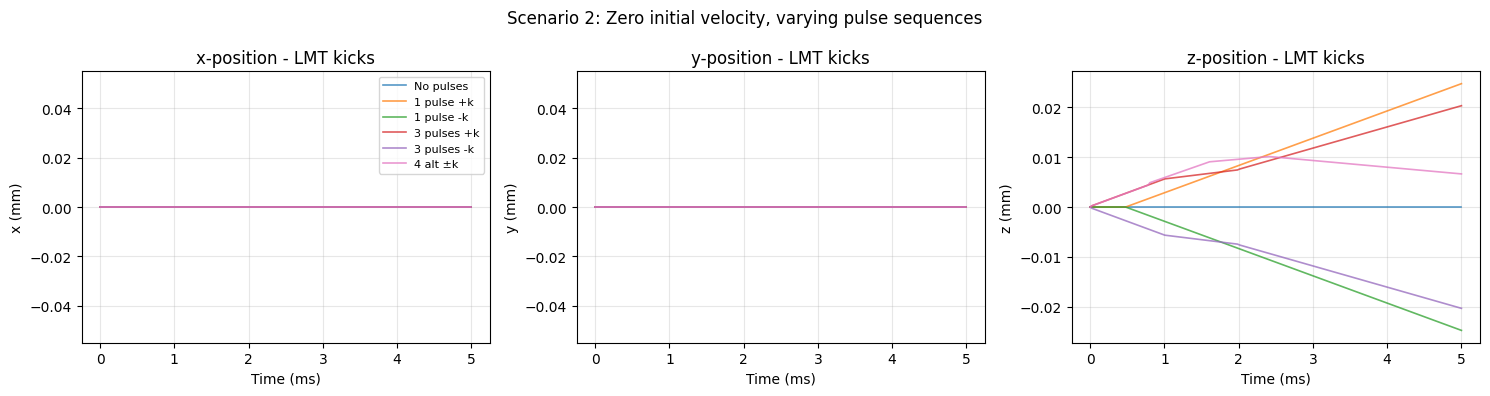

In [24]:
# Each atom starts at rest; pulses impart momentum kicks at evenly spaced times.
# We try different numbers of +k / -k pulse sequences.
pulse_cases = [
    (0,  [],         'No pulses'),
    (1,  [(0.5e-3, +1)],              '1 pulse +k'),
    (1,  [(0.5e-3, -1)],              '1 pulse -k'),
    (3,  [(i*1e-3, +1) for i in range(3)],      '3 pulses +k'),
    (3,  [(i*1e-3, -1) for i in range(3)],      '3 pulses -k'),
    (4,  [(i*0.8e-3, +1 if i%2==0 else -1) for i in range(4)], '4 alt ±k'),
]

colors2 = cm.tab10(np.linspace(0, 0.6, len(pulse_cases)))
trajectories2 = []
labels2 = []

for _n, schedule, label in pulse_cases:
    t, traj = simulate_trajectory(
        position_xyz=np.zeros(3),
        velocity_xyz=np.zeros(3),
        pulse_schedule=schedule,
    )
    trajectories2.append(traj)
    labels2.append(label)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
plot_xyz_trajectories(*axes2, times_ms, trajectories2, labels=labels2, colors=colors2,
                      title_suffix='LMT kicks')
axes2[0].legend(fontsize=8)
fig2.suptitle('Scenario 2: Zero initial velocity, varying pulse sequences', fontsize=12)
vs.tag_plot(small=True)
fig2.tight_layout()
plt.show()

## 3 · Maxwell–Boltzmann ensemble at 1 µK with pulses

1 µK thermal velocity σ = 9.7759 mm/s  (1.49 v_recoil)


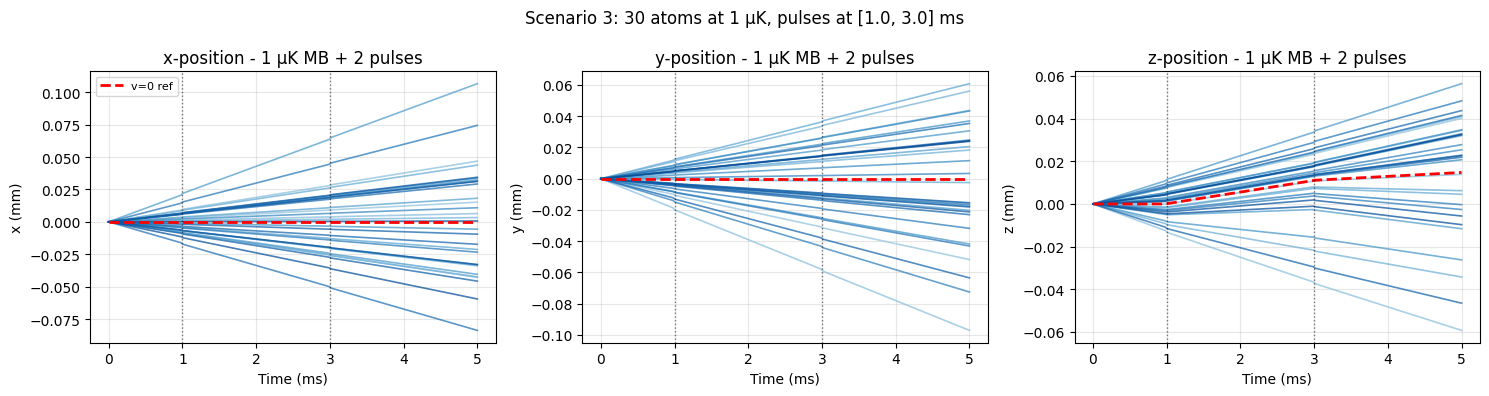

In [25]:
TEMPERATURE = 1e-6   # 1 µK
N_ATOMS = 30

rng3 = np.random.default_rng(42)
velocities3 = maxwell_boltzmann_velocities(TEMPERATURE, N_ATOMS, rng=rng3)

sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
print(f'1 µK thermal velocity σ = {sigma_v*1e3:.4f} mm/s  ({sigma_v/RECOIL_VELOCITY:.2f} v_recoil)')

# Two π-pulses at 1 ms and 3 ms, both +k
pulse_schedule3 = [(1e-3, +1), (3e-3, +1)]

trajectories3 = []
for vel in velocities3:
    t, traj = simulate_trajectory(
        position_xyz=np.zeros(3),
        velocity_xyz=vel,
        pulse_schedule=pulse_schedule3,
    )
    trajectories3.append(traj)

# Also add a zero-velocity reference
t, traj_ref3 = simulate_trajectory(np.zeros(3), np.zeros(3), pulse_schedule3)

fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors3 = [cm.Blues(0.4 + 0.5 * i / N_ATOMS) for i in range(N_ATOMS)]
plot_xyz_trajectories(*axes3, times_ms, trajectories3, colors=colors3,
                      title_suffix='1 µK MB + 2 pulses')
# Overlay zero-velocity reference
for ax, dim in zip(axes3, ['x', 'y', 'z']):
    ax.plot(times_ms, traj_ref3[dim] * 1e3, 'r--', lw=2, label='v=0 ref')
    # Mark pulse times
    for tp, _ in pulse_schedule3:
        ax.axvline(tp * 1e3, color='k', ls=':', lw=1, alpha=0.5)
axes3[0].legend(fontsize=8)
fig3.suptitle(f'Scenario 3: {N_ATOMS} atoms at 1 µK, pulses at {[tp*1e3 for tp,_ in pulse_schedule3]} ms', fontsize=12)
vs.tag_plot(small=True)
fig3.tight_layout()
plt.show()

## 4 · 1 µK velocities **and** initial position spread (~100 µm)

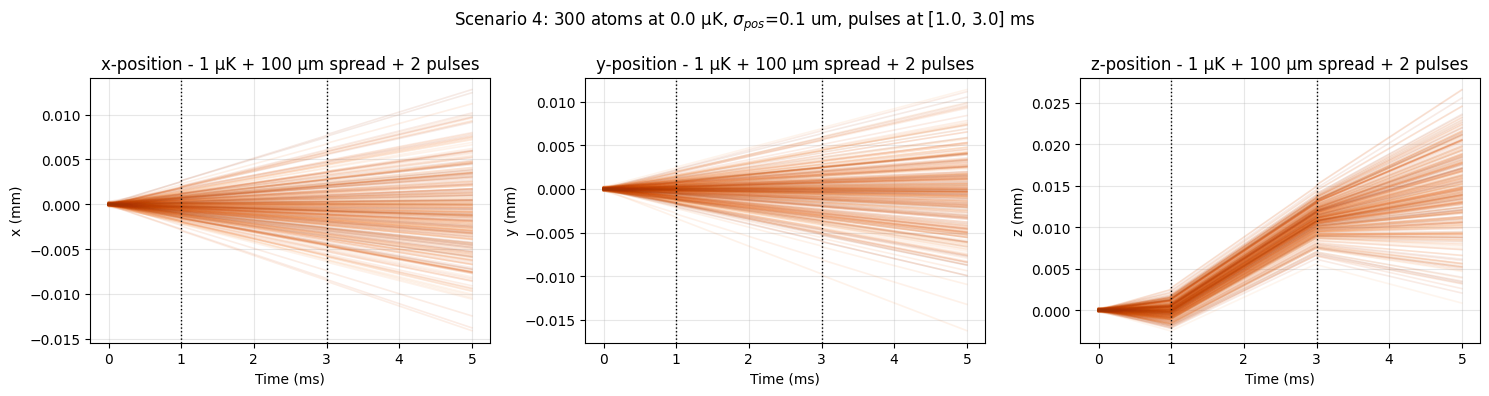

In [44]:
POSITION_SIGMA = 100e-9
N_ATOMS4 = 300
TEMPERATURE = 10e-9

rng4 = np.random.default_rng(7)
velocities4 = maxwell_boltzmann_velocities(TEMPERATURE, N_ATOMS4, rng=rng4)
positions4 = rng4.normal(0.0, POSITION_SIGMA, size=(N_ATOMS4, 3))

# Same pulse schedule as scenario 3
pulse_schedule4 = [(1e-3, +1), (3e-3, +1)]

trajectories4 = []
for pos, vel in zip(positions4, velocities4):
    t, traj = simulate_trajectory(
        position_xyz=pos,
        velocity_xyz=vel,
        pulse_schedule=pulse_schedule4,
    )
    trajectories4.append(traj)

fig4, axes4 = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors4 = [cm.Oranges(0.4 + 0.5 * i / N_ATOMS4) for i in range(N_ATOMS4)]
plot_xyz_trajectories(*axes4, times_ms, trajectories4, colors=colors4, alpha=0.1,
                      title_suffix='1 µK + 100 µm spread + 2 pulses')
for ax, dim in zip(axes4, ['x', 'y', 'z']):
    for tp, _ in pulse_schedule4:
        ax.axvline(tp * 1e3, color='k', ls=':', lw=1, alpha=1.0)
fig4.suptitle(
    f'Scenario 4: {N_ATOMS4} atoms at {TEMPERATURE*1e6:.1f} µK, $\\sigma_{{pos}}$={POSITION_SIGMA*1e6:.1f} um, pulses at {[tp*1e3 for tp,_ in pulse_schedule4]} ms',
    fontsize=12
)
vs.tag_plot(small=True)
fig4.tight_layout()
plt.show()